# Data Understanding


# 1.Identifiers :

id, spkid, full_name, pdes, name, prefix, orbit_id

# 2.Flags :

neo → Is it a Near-Earth Object? (yes/no).

pha → Is it a Potentially Hazardous Asteroid? (yes/no).

# 3. Size & Brightness:

H → Absolute magnitude (brightness). Lower H = larger/brighter asteroid.

diameter → Diameter in km (can be a regression target).

albedo → Reflectivity of the surface (dark vs bright).

diameter_sigma → Uncertainty in diameter measurement.

# 4. Orbit:

e → Orbit eccentricity (circle vs oval).

a → Semi-major axis (average distance to Sun).

q → Perihelion distance (closest to Sun).

i → Inclination (tilt of orbit relative to Earth's plane).

ad → Aphelion distance (farthest from Sun).

n → Mean motion (orbital speed, degrees/day).

per → Orbital period in days.

# 5. Closeness to Earth:

moid → Minimum Orbit Intersection Distance with Earth (in AU).

moid_ld → Same distance in Lunar Distances.

# 6.Other (less important):

om, w, ma, tp → Angles and times in orbit .

class → Orbit type (Apollo, Amor, Aten, etc.).

rms → RMS error of orbit fit (data quality).

sigma\_\* → Measurement uncertainties.


In [3]:
#Importing libraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.preprocessing import StandardScaler,RobustScaler,LabelEncoder
from sklearn.model_selection import train_test_split

In [4]:
#Reading data
df = pd.read_csv(r"C:\Users\habib\OneDrive\Desktop\GDG_AI\Data Sets\Astroid_data.csv")

C:\Users\habib\AppData\Local\Temp\ipykernel_412\477558587.py:2: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\habib\OneDrive\Desktop\GDG_AI\Data Sets\Astroid_data.csv")


# EDA


In [5]:
df.head()

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [6]:
print(f"The dataset shape : {df.shape}")

The dataset shape : (958524, 45)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [8]:
df.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [9]:
# The precentage of null values in each column
print("Missing value percentage in each column")
(df.isna().sum()/len(df)*100).sort_values(ascending=False)

Missing value percentage in each column


prefix            99.998122
name              97.698128
albedo            85.905100
diameter_sigma    85.803068
diameter          85.789714
sigma_per          2.078821
sigma_ad           2.078821
sigma_om           2.078404
sigma_ma           2.078404
sigma_q            2.078404
sigma_a            2.078404
sigma_w            2.078404
sigma_i            2.078404
sigma_tp           2.078404
sigma_e            2.078404
sigma_n            2.078404
moid               2.078300
pha                2.078300
H                  0.653400
moid_ld            0.013250
neo                0.000417
ad                 0.000417
per                0.000417
rms                0.000209
per_y              0.000104
ma                 0.000104
id                 0.000000
full_name          0.000000
pdes               0.000000
orbit_id           0.000000
spkid              0.000000
tp_cal             0.000000
om                 0.000000
w                  0.000000
tp                 0.000000
n                  0

In [10]:
print(f"Number of duplicated rows : {df.duplicated().sum()}")

Number of duplicated rows : 0


<Axes: >

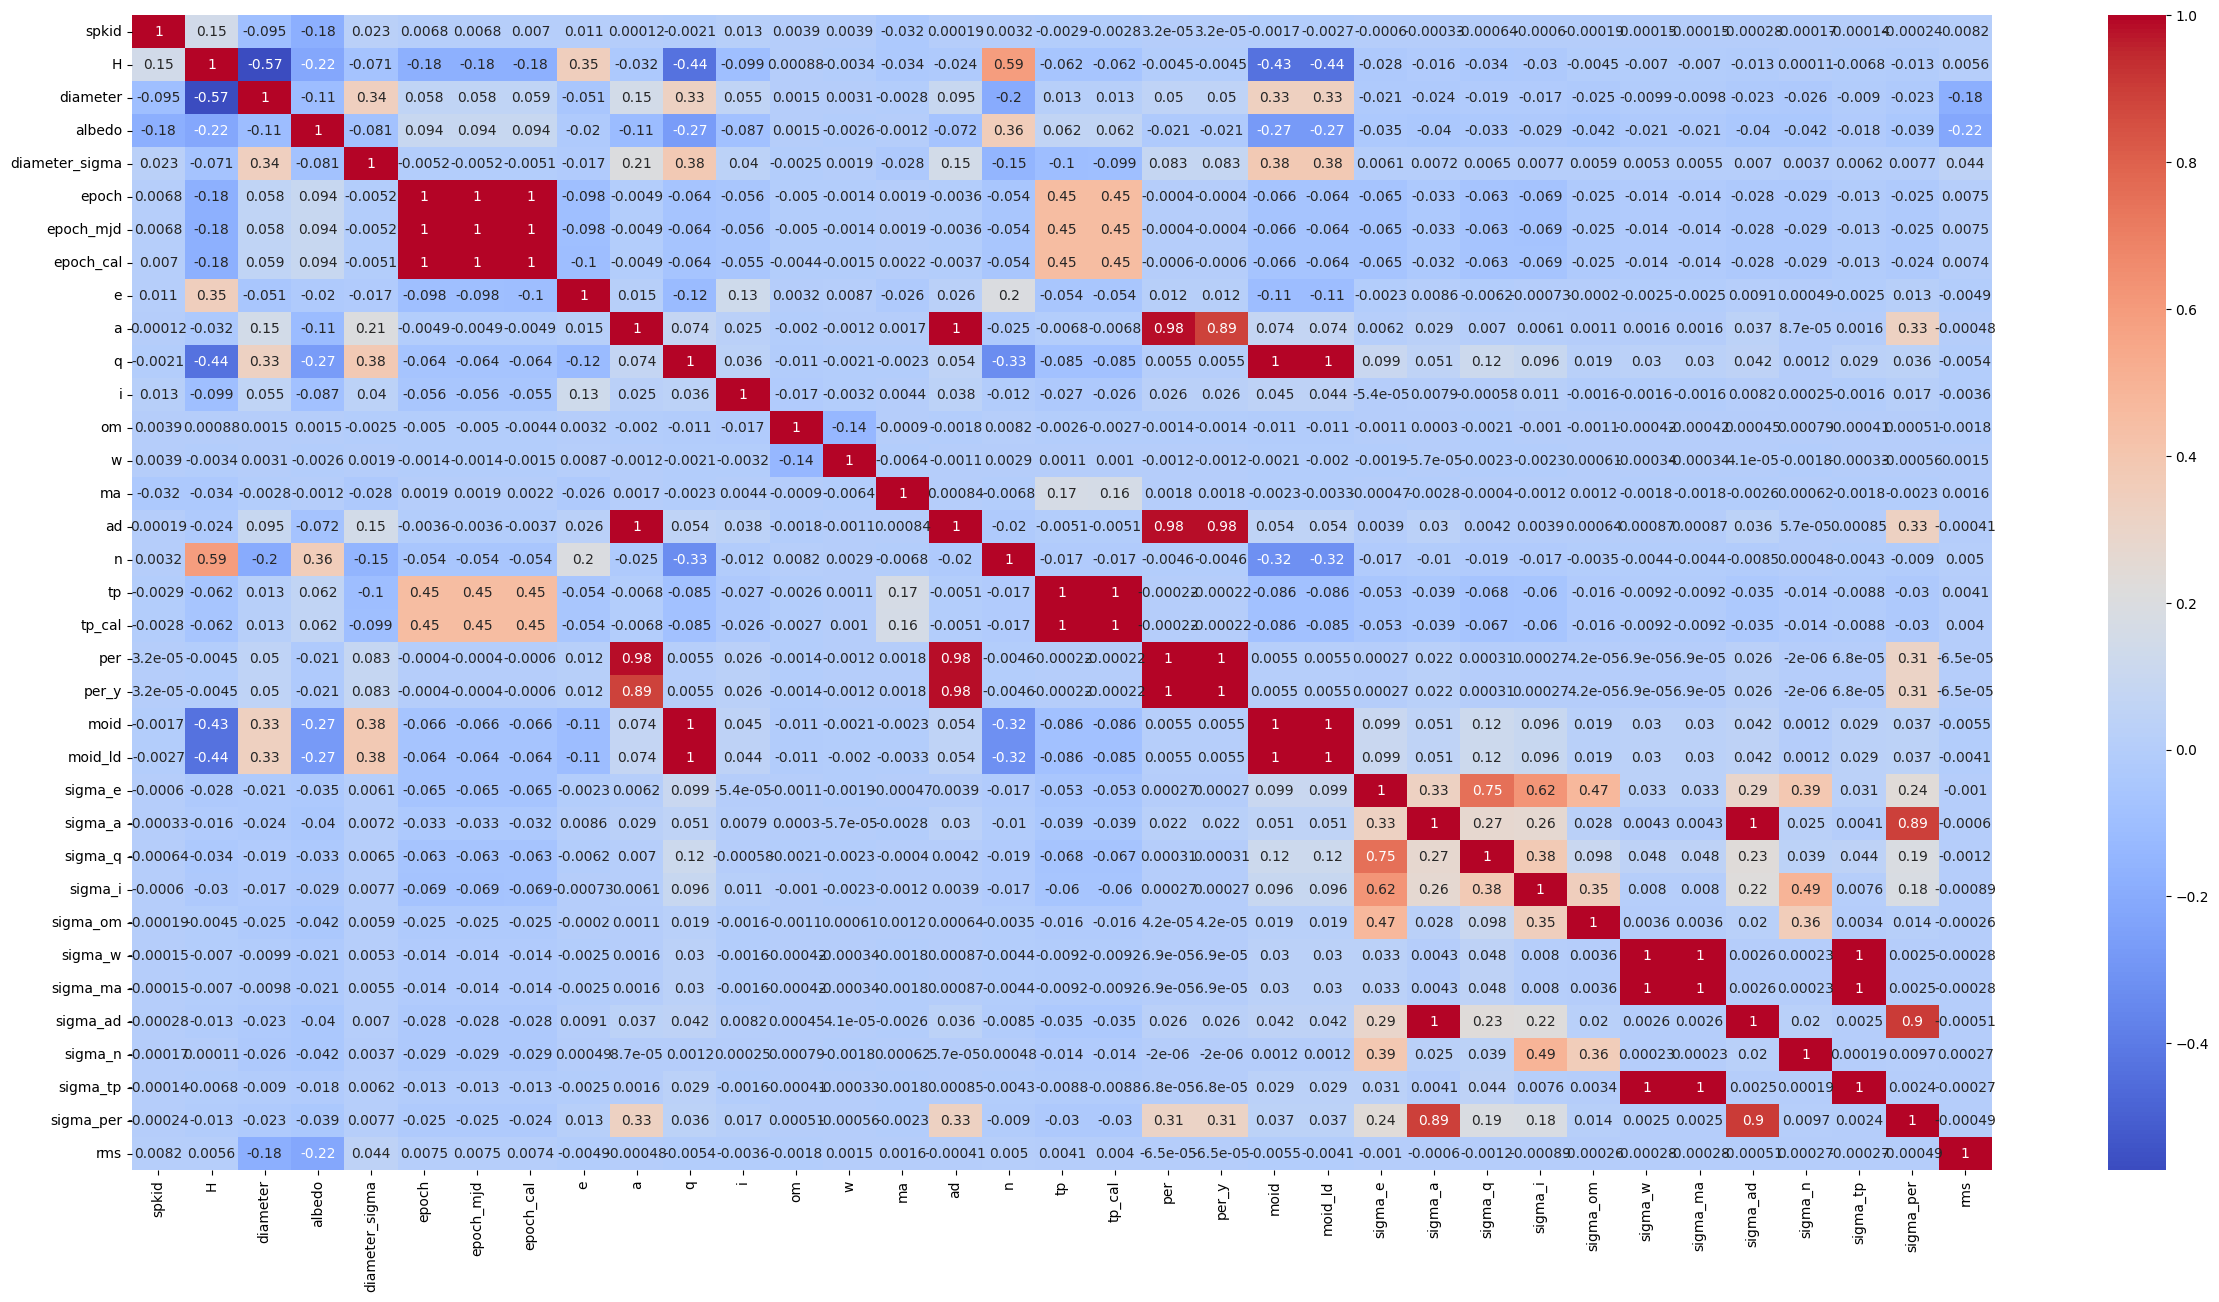

In [11]:
# Discovering the relation between the fetures and target (diameter)
nummeric_data = df.drop(df.select_dtypes(include=['object']).columns, axis=1)
plt.figure(figsize=(30,15))
sns.heatmap(nummeric_data.corr(), annot=True, cmap="coolwarm")

In [12]:
#droping the columns that isn't affect the target (diameter)
df=df.drop(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id','epoch','equinox',
           'epoch_mjd', 'epoch_cal','i', 'om', 'w','ma','tp', 'tp_cal', 'per', 'per_y','sigma_e', 'sigma_a',
           'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w','sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per'],axis=1)

In [13]:
print(f" Shape after droping unnessesary columns : {df.shape}")

 Shape after droping unnessesary columns : (958524, 15)


In [14]:
df.columns

Index(['neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'e', 'a',
       'q', 'ad', 'n', 'moid', 'moid_ld', 'class', 'rms'],
      dtype='object')

In [15]:
# Renaming columns
col_rename={
  'neo':'is_near' ,
   'pha':'is_hazardous',
   'H':'brightness',
   'albedo':'reflectivity',
   'diameter_sigma':'diameter_error',
    'e':'orbit_eccentricity',
    'a':'semi_major_axis',
    'q':'perihelion_dist',
    'ad':'aphelion_dist',
    'n':'orbital_speed',
}
df=df.rename(columns=col_rename)
df.head()


,is_near,is_hazardous,brightness,diameter,reflectivity,diameter_error,orbit_eccentricity,semi_major_axis,perihelion_dist,aphelion_dist,orbital_speed,moid,moid_ld,class,rms
0,N,N,3.40,939.400,0.0900,0.200,0.076009,2.769165,2.558684,2.979647,0.213885,1.59478,620.640533,MBA,0.43301
1,N,N,4.20,545.000,0.1010,18.000,0.229972,2.773841,2.135935,3.411748,0.213345,1.23429,480.348639,MBA,0.35936
2,N,N,5.33,246.596,0.2140,10.594,0.256936,2.668285,1.982706,3.353865,0.226129,1.03429,402.514639,MBA,0.33848
3,N,N,3.00,525.400,0.4228,0.200,0.088721,2.361418,2.151909,2.570926,0.271609,1.13948,443.451432,MBA,0.39980
4,N,N,6.90,106.699,0.2740,3.140,0.190913,2.574037,2.082619,3.065455,0.238661,1.09575,426.433027,MBA,0.52191


# Preprocessing


In [16]:
#drop the null values in the target column
df=df.dropna(subset=["diameter"])
print(f"Shape after droping the target nulls :{df.shape}")

Shape after droping the target nulls :(136209, 15)


In [17]:
#null percentage in each column
print("Missing value percentage in each column after dropping the diameter nulls :")
(df.isna().sum()/len(df)*100).sort_values(ascending=False)

Missing value percentage in each column after dropping the diameter nulls :


brightness            3.057067
reflectivity          0.814190
diameter_error        0.093973
is_hazardous          0.000000
is_near               0.000000
diameter              0.000000
orbit_eccentricity    0.000000
semi_major_axis       0.000000
perihelion_dist       0.000000
aphelion_dist         0.000000
orbital_speed         0.000000
moid                  0.000000
moid_ld               0.000000
class                 0.000000
rms                   0.000000
dtype: float64

In [18]:
df.describe()

,brightness,diameter,reflectivity,diameter_error,orbit_eccentricity,semi_major_axis,perihelion_dist,aphelion_dist,orbital_speed,moid,moid_ld,rms
count,132045.000000,136209.000000,135100.000000,136081.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000,136209.000000
mean,15.132319,5.506429,0.130625,0.479184,0.145660,2.819158,2.406130,3.232187,0.219086,1.423858,554.122719,0.544153
std,1.387944,9.425164,0.110323,0.782895,0.077464,1.495980,0.516931,2.839820,0.056912,0.513029,199.655301,0.073617
min,3.000000,0.002500,0.001000,0.000500,0.000060,0.626210,0.081820,0.999954,0.000135,0.000027,0.010335,0.054414
25%,14.400000,2.780000,0.053000,0.180000,0.089878,2.542856,2.072478,2.871056,0.181012,1.086220,422.724237,0.508920
50%,15.200000,3.972000,0.079000,0.332000,0.138919,2.754950,2.368605,3.173515,0.215543,1.389580,540.782849,0.544180
75%,16.000000,5.765000,0.190000,0.620000,0.191174,3.095029,2.688275,3.472570,0.243064,1.702400,662.523008,0.579260
max,29.900000,939.400000,1.000000,140.000000,0.983789,376.133297,40.318477,746.169105,1.988951,39.360300,15317.847951,7.725100


Text(0.5, 0.98, 'Distribution of Features with Missing Values')

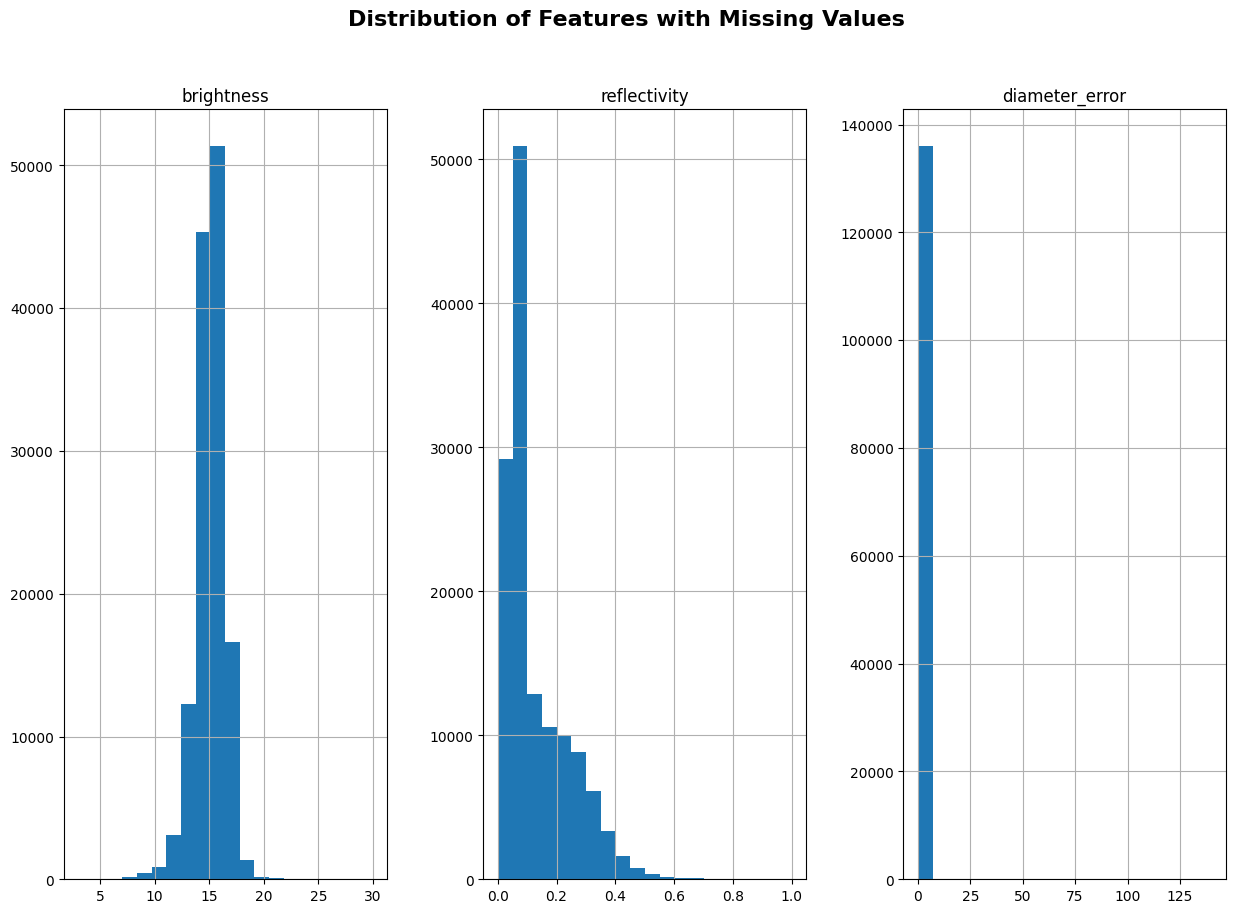

In [19]:
cols=['brightness','reflectivity','diameter_error']
df[cols].hist(bins=20, figsize=(15, 10), layout=(1,3))
plt.suptitle("Distribution of Features with Missing Values",fontsize=16,fontweight="bold")

- The **brightness** column is approximately normally distributed, so missing values can be imputed using the **mean**.

- The **reflectivity** and **diameter_error** columns are right-skewed, so missing values should be imputed using the **median**.


In [20]:
#imputing the missing values
df['brightness'] = df['brightness'].fillna(df['brightness'].mean())
df['reflectivity'] = df['reflectivity'].fillna(df['reflectivity'].median())
df['diameter_error'] = df['diameter_error'].fillna(df['diameter_error'].median())

print(f"The number of missing values : ")
print(df.isna().sum())


The number of missing values : 
is_near               0
is_hazardous          0
brightness            0
diameter              0
reflectivity          0
diameter_error        0
orbit_eccentricity    0
semi_major_axis       0
perihelion_dist       0
aphelion_dist         0
orbital_speed         0
moid                  0
moid_ld               0
class                 0
rms                   0
dtype: int64


In [21]:
#Function for printing outliers report
def outlier_report (cols):
    outlier_data = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound = Q1-1.5*IQR
        upper_bound = Q3+1.5*IQR
        
        outlier_count = ((df[col]<lower_bound)|(df[col]>upper_bound)).sum()
        outlier_per = (outlier_count/len(df))*100
        outlier_data.append([col,outlier_count,outlier_per])
        
    outlier_df = pd.DataFrame(outlier_data,columns=['Column','Outliers Count','Outliers %'])
    outlier_df = outlier_df.sort_values(by ='Outliers Count',ascending=False)
    print(outlier_df.to_string(index=False))

In [22]:
#counting outliers
num_cols=df.select_dtypes('number')
outlier_report(num_cols)  

            Column  Outliers Count  Outliers %
          diameter            9613    7.057537
    diameter_error            6878    5.049593
               rms            4954    3.637058
      reflectivity            3809    2.796438
     aphelion_dist            3567    2.618770
        brightness            3532    2.593074
   semi_major_axis            3423    2.513050
     orbital_speed            3253    2.388242
   perihelion_dist            2708    1.988121
              moid            2552    1.873591
           moid_ld            2552    1.873591
orbit_eccentricity            1503    1.103451


Text(0.5, 1.05, 'Outlier Detection using Boxplots')

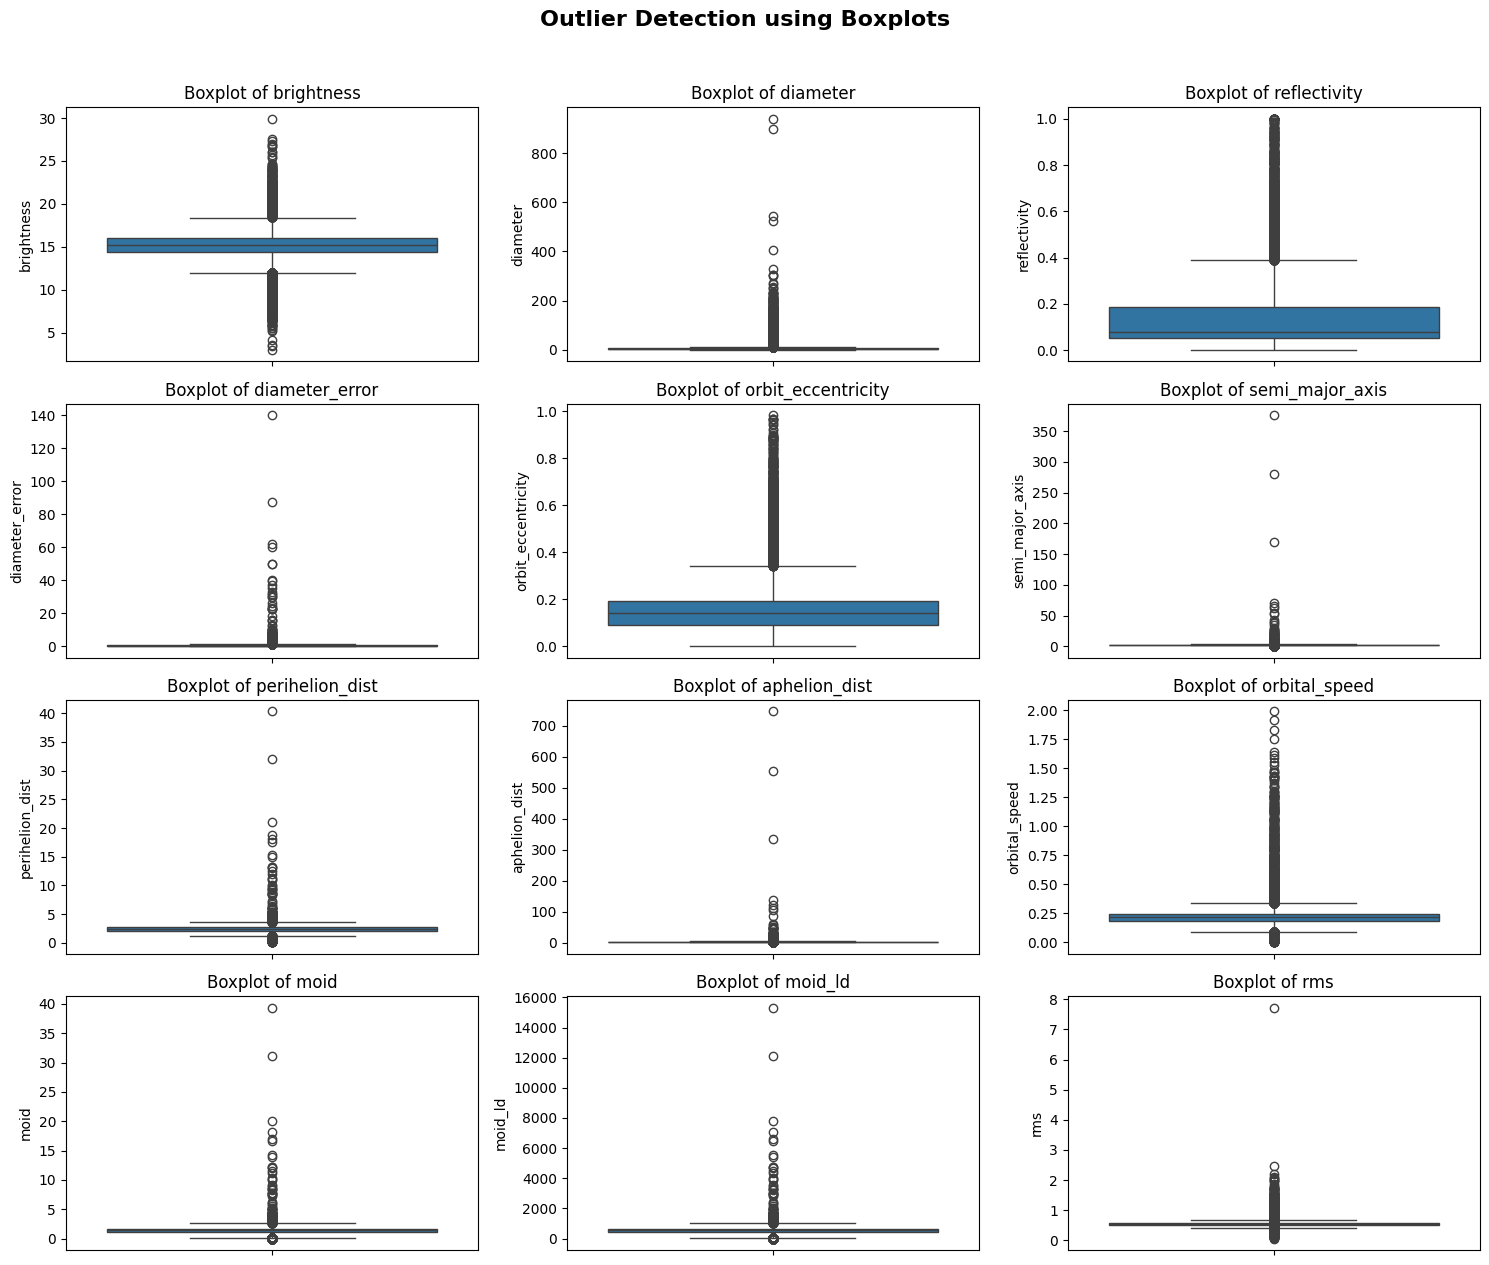

In [23]:
#Box plot for each column
features = num_cols.columns.tolist()

rows = 4
cols_per_row = 3
plt.figure(figsize=(15, 12))

for i, feature in enumerate(features, start=1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.tight_layout()

plt.suptitle("Outlier Detection using Boxplots", fontsize=16,fontweight="bold",y=1.05)

In [24]:
#Removing outliers from diameter column
Q1 = df['diameter'].quantile(0.25)
Q3 = df['diameter'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
df = df[(df['diameter']>lower_bound)&(df['diameter']<upper_bound)]

print(f" Shape after droping the diameter column outliers : {df.shape}")

 Shape after droping the diameter column outliers : (126596, 15)


In [25]:
#Capping outliers in the remaining columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, np.where(df[col] > upper_bound, upper_bound, df[col]))

In [26]:
#counting outliers
outlier_report(num_cols)  

            Column  Outliers Count  Outliers %
        brightness               0         0.0
          diameter               0         0.0
      reflectivity               0         0.0
    diameter_error               0         0.0
orbit_eccentricity               0         0.0
   semi_major_axis               0         0.0
   perihelion_dist               0         0.0
     aphelion_dist               0         0.0
     orbital_speed               0         0.0
              moid               0         0.0
           moid_ld               0         0.0
               rms               0         0.0


In [27]:
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    print (df[col].value_counts())

is_near
N    125751
Y       845
Name: count, dtype: int64
is_hazardous
N    126375
Y       221
Name: count, dtype: int64
class
MBA    118480
OMB      6211
IMB       564
APO       486
MCA       350
AMO       264
TJN       129
ATE        95
CEN        12
AST         3
TNO         2
Name: count, dtype: int64


Text(0.5, 1.0, 'Countplot of class')

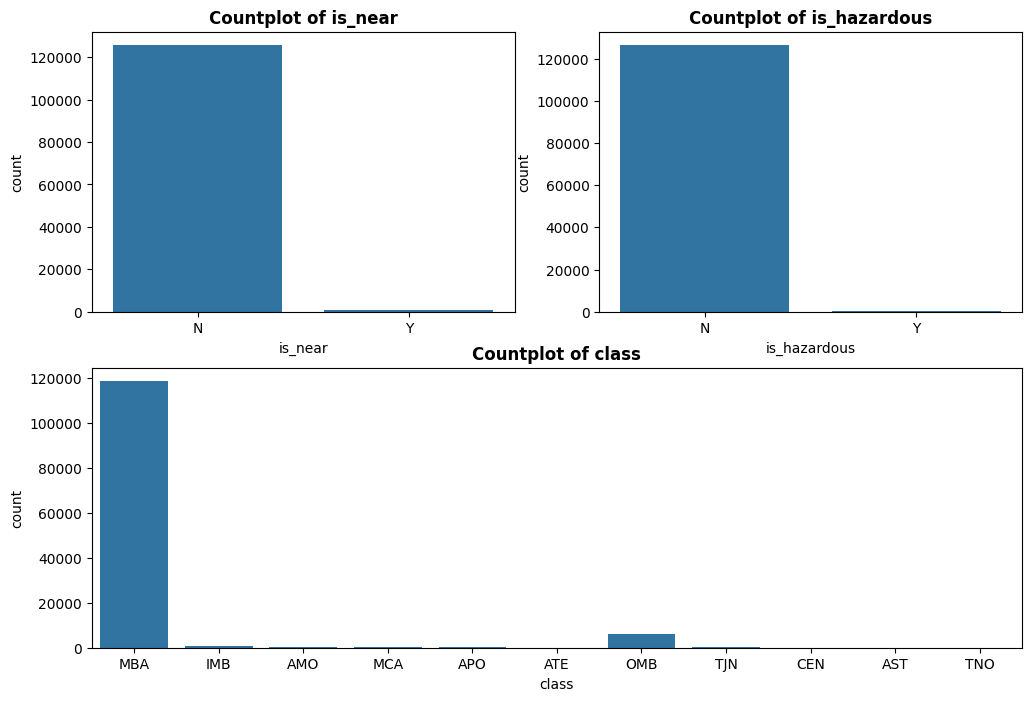

In [28]:
#Countplots for object columns
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2) 

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax3 = fig.add_subplot(gs[1, :])

sns.countplot(x=df[obj_cols[0]], ax=ax1)
ax1.set_title(f"Countplot of {obj_cols[0]}", fontweight="bold", fontsize=12)

sns.countplot(x=df[obj_cols[1]], ax=ax2)
ax2.set_title(f"Countplot of {obj_cols[1]}", fontweight="bold", fontsize=12)

sns.countplot(x=df[obj_cols[2]], ax=ax3)
ax3.set_title(f"Countplot of {obj_cols[2]}", fontweight="bold", fontsize=12)

Text(0.5, 1.05, 'Features vs Target ')

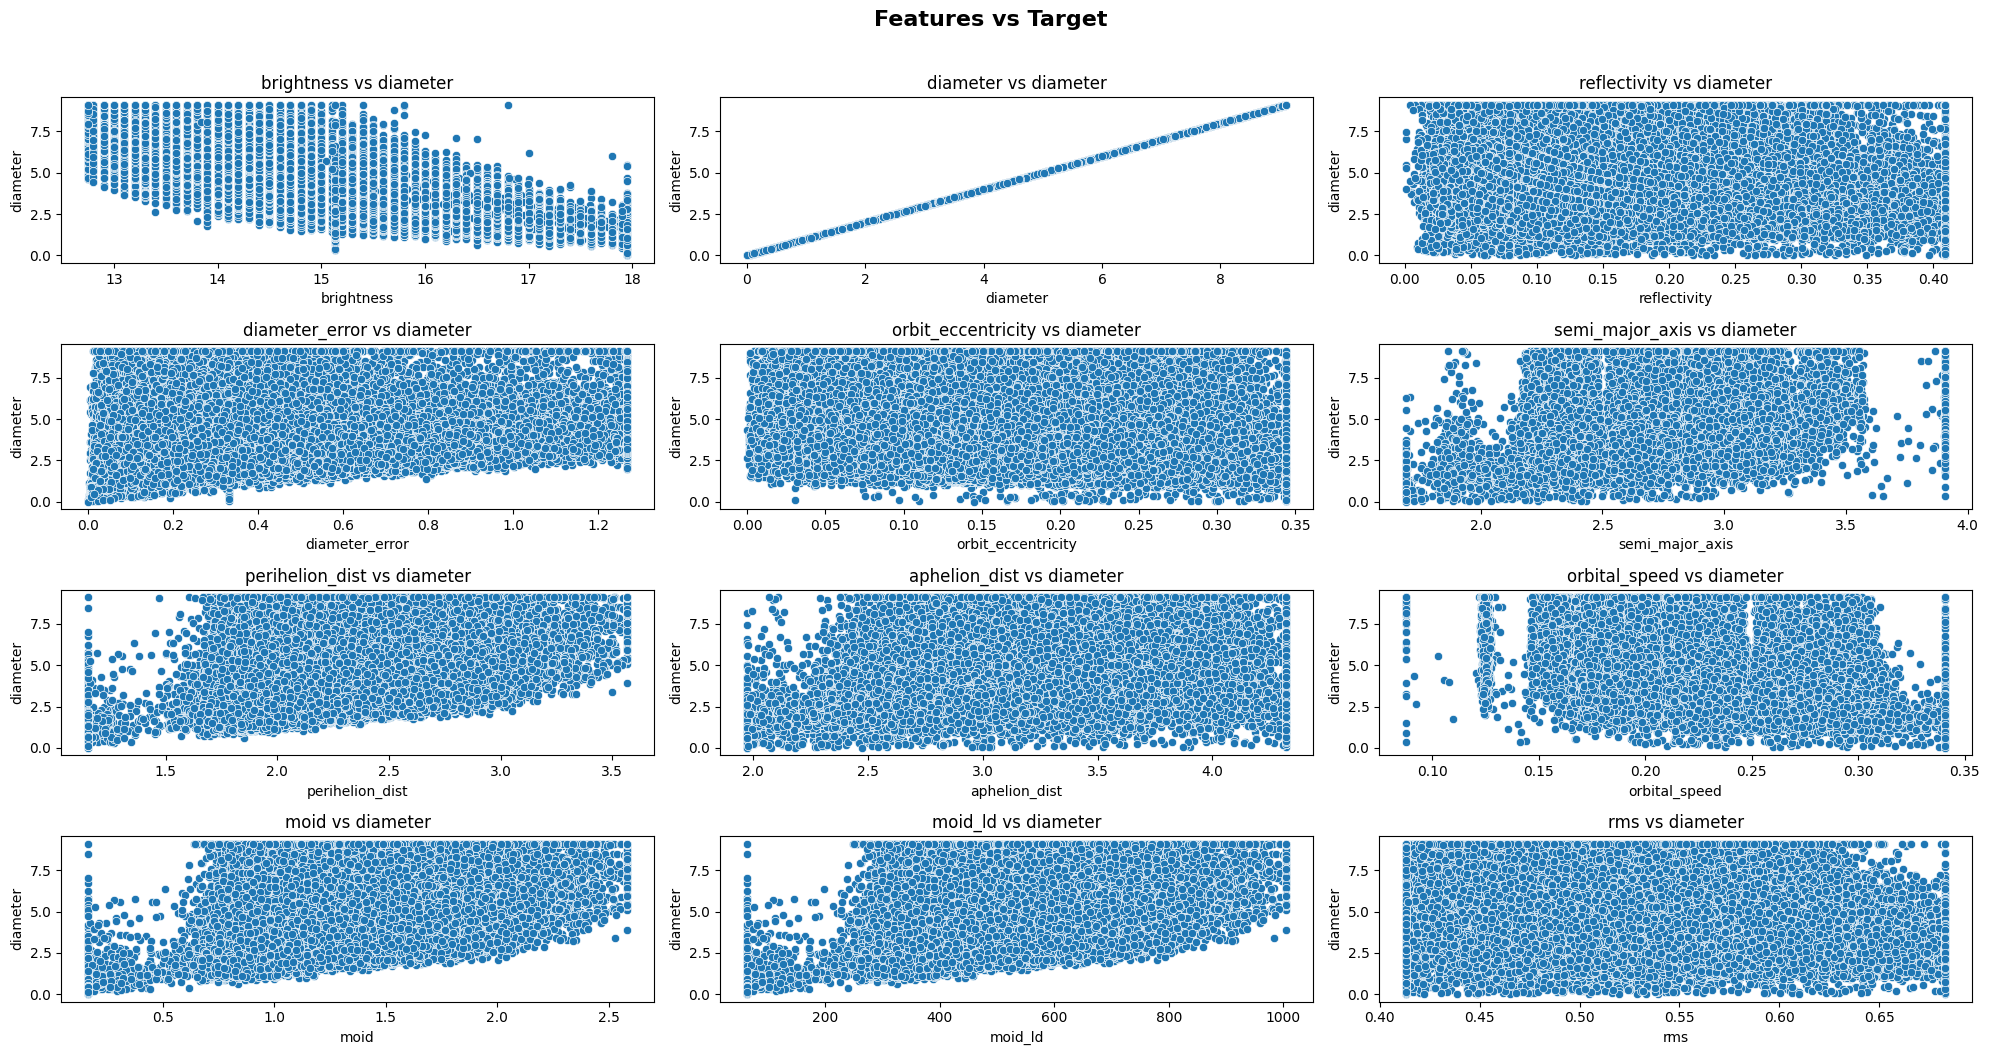

In [29]:
#Feature vs target scatterplots 
features = num_cols.columns.to_list()
row = 4
cols_per_row=3
plt.figure(figsize=(20,10))

for i,feature in enumerate(features,start=1):
    plt.subplot(row , cols_per_row,i)
    sns.scatterplot(x=feature,y=df['diameter'],data=df)
    plt.title(f"{feature} vs diameter" )
    plt.tight_layout()

plt.suptitle("Features vs Target ", fontsize=16 ,fontweight ="bold" ,y=1.05)
    

In [30]:
#Data splitting
x = df.drop('diameter',axis=1)
y= df['diameter']

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=.2,random_state=42)

In [31]:
#Encoding
for col in obj_cols:
    le=LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])

In [32]:
#Scaling
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

# Modeling


In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1)
}

results = []

# Loop through models
for name, model in models.items():
    model.fit(x_train_s, y_train)
    y_pred = model.predict(x_test_s)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({'Model': name, 'R²': r2, 'RMSE': rmse})
    print(f"{name:18s}: R² = {r2:.3f}, RMSE = {rmse:.3f}")


Linear Regression : R² = 0.801, RMSE = 0.849
Ridge Regression  : R² = 0.801, RMSE = 0.849
Lasso Regression  : R² = 0.785, RMSE = 0.884


In [34]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# 2. RANDOM FOREST 
print(f"RANDOM FOREST")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"R²: {rf_r2:.3f}")
print(f"RMSE: {rf_rmse:.3f}")

RANDOM FOREST
R²: 0.949
RMSE: 0.430


In [35]:
import xgboost as xgb

# 3. XGBOOST
print(f"XGBOOST")
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"R²: {xgb_r2:.3f}")
print(f"RMSE: {xgb_rmse:.3f}")

XGBOOST
R²: 0.950
RMSE: 0.426
